# Assignment IV – B.1: Ocean Current Simulation with Dask

## Imports and Setup

In [ ]:
import numpy as np
import dask.array as da
import matplotlib.pyplot as plt
import time

from dask.distributed import Client, LocalCluster

cluster = LocalCluster()
client = Client(cluster)
print(f"Dask Dashboard: {client.dashboard_link}")

Dask Dashboard: http://127.0.0.1:8787/status


## Initialize Ocean Grid

In [8]:
GRID_SIZE = 200
TIME_STEPS = 100
np.random.seed(42)

temperature_np = np.random.uniform(5, 30, size=(GRID_SIZE, GRID_SIZE))
u_np = np.random.uniform(-1,  1, size=(GRID_SIZE, GRID_SIZE))
v_np = np.random.uniform(-1,  1, size=(GRID_SIZE, GRID_SIZE))
wind_np = np.random.uniform(-0.5, 0.5, size=(GRID_SIZE, GRID_SIZE))

print(f"Grid: {GRID_SIZE} x {GRID_SIZE}")

Grid: 200 x 200


## Serial Simulation and Timing

In [3]:
def laplacian_np(field):
    return (
        np.roll(field, 1, axis=0) + np.roll(field, -1, axis=0) +
        np.roll(field, 1, axis=1) + np.roll(field, -1, axis=1) -
        4 * field
    )

def update_ocean_np(u, v, temp, wind, alpha=0.1, beta=0.02):
    u_new = u + alpha * laplacian_np(u) + beta * wind
    v_new = v + alpha * laplacian_np(v) + beta * wind
    temp_new = temp + 0.01 * laplacian_np(temp)
    return u_new, v_new, temp_new

u, v, temp = u_np.copy(), v_np.copy(), temperature_np.copy()

t0 = time.perf_counter()
for t in range(TIME_STEPS):
    u, v, temp = update_ocean_np(u, v, temp, wind_np)
serial_time = time.perf_counter() - t0
print(f"Serial time: {serial_time:.3f}s")

u_serial, v_serial, temp_serial = u, v, temp

Serial time: 0.078s


## Serial Visualization

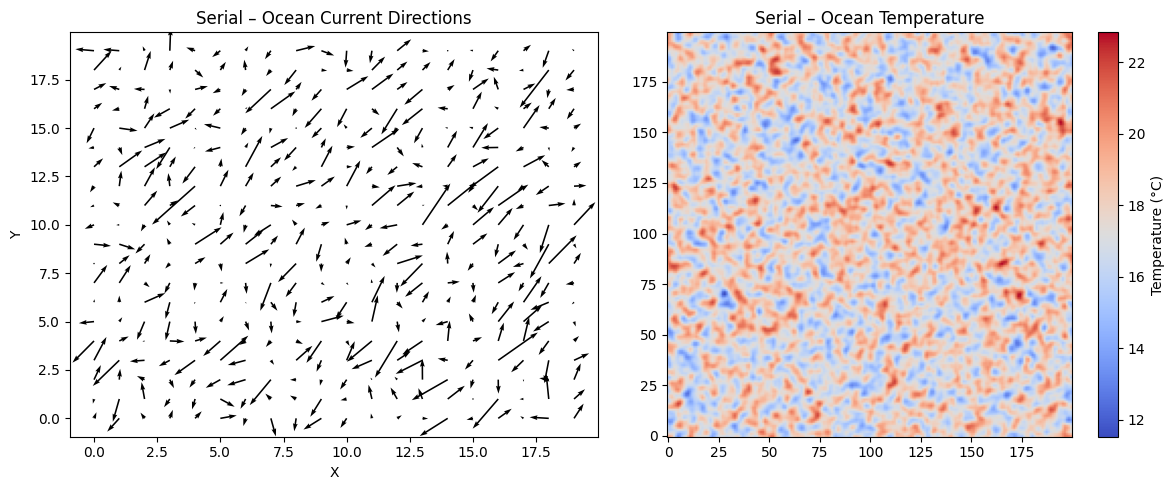

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].quiver(u_serial[::10, ::10], v_serial[::10, ::10])
axes[0].set_title("Serial - Ocean Current Directions")
axes[0].set_xlabel("X"); axes[0].set_ylabel("Y")

im = axes[1].imshow(temp_serial, cmap='coolwarm', origin='lower')
fig.colorbar(im, ax=axes[1], label="Temperature (°C)")
axes[1].set_title("Serial - Ocean Temperature")

plt.tight_layout()
plt.show()

## Dask Parallel Simulation using `map_overlap`

In [9]:
CHUNK = (100, 100)  

u_da = da.from_array(u_np.copy(), chunks=CHUNK)
v_da = da.from_array(v_np.copy(), chunks=CHUNK)
temp_da = da.from_array(temperature_np.copy(), chunks=CHUNK)
wind_da = da.from_array(wind_np.copy(), chunks=CHUNK)

def laplacian_kernel(field):
    lap = (
        np.roll(field, 1, axis=0) + np.roll(field, -1, axis=0) +
        np.roll(field, 1, axis=1) + np.roll(field, -1, axis=1) -
        4 * field
    )
    return lap

def update_ocean_dask(u, v, temp, wind, alpha=0.1, beta=0.02):
    lap_u = da.overlap.map_overlap(
        laplacian_kernel, u, depth=1, boundary='reflect', dtype=u.dtype
    )
    lap_v = da.overlap.map_overlap(
        laplacian_kernel, v, depth=1, boundary='reflect', dtype=v.dtype
    )
    lap_t = da.overlap.map_overlap(
        laplacian_kernel, temp, depth=1, boundary='reflect', dtype=temp.dtype
    )

    u_new = u + alpha * lap_u + beta * wind
    v_new = v + alpha * lap_v + beta * wind
    temp_new = temp + 0.01 * lap_t
    return u_new, v_new, temp_new

t0 = time.perf_counter()
for t in range(TIME_STEPS):
    u_da, v_da, temp_da = update_ocean_dask(u_da, v_da, temp_da, wind_da)

u_da_, v_da_, temp_da_ = da.compute(u_da, v_da, temp_da)
dask_time = time.perf_counter() - t0

print(f"Dask time (chunk={CHUNK}): {dask_time:.3f}s")
print(f"Serial time: {serial_time:.3f}s")
print(f"Speedup: {serial_time / dask_time:.2f}x")

Dask time (chunk=(100, 100)): 11.462s
Serial time: 0.078s
Speedup: 0.01x


## Conclusion: Why is Dask slower here?

It is perfectly normal and expected that Dask is significantly slower for this specific configuration. Here is why:

1. **Tiny Array Size:** A `200x200` array easily fits entirely inside a single CPU's L1/L2 cache. NumPy can process this in milliseconds without any overhead. 
2. **Scheduler Overhead:** Constructing the Dask task graph for 100 iterative time loops takes far more time than the actual mathematical computations.
3. **Heavy Communication Cost:** To compute the Laplacian, `map_overlap` must constantly exchange "ghost cells" (the edges of the chunks) between workers across all 100 time steps. The time spent communicating between chunks completely overshadows the computation time.

Dask shines on massive datasets but introduces massive communication and scheduling overhead for highly iterative, tiny-scale problems.

## Task B.2: Monitor Performance with the Dask Dashboard

*Task B2.1 Instructions:* 

*(Observations)*
- **Task Stream Observation:** There are many small boxes representing small individual tasks. The gaps between them demonstrate the massive scheduler and communication overhead of running `map_overlap` edge-exchange per-time step on a small 200x200 array.
- **Worker CPU/Memory Observation:** 
  
  As seen in the screenshot below, all logically available worker threads are successfully engaged. Overall, they push CPU usage to roughly 50%-70% per worker. Memory consumption remains incredibly low (around 70-80 MB per worker) because the 200x200 chunks are extremely small in terms of raw bytes.
  
  ![Dask Workers Dashboard](Screenshot%202026-03-08%20at%2020.19.36.png)

### Task B2.2 - Experiment with Different Chunk Sizes

Based on the **Chunk-Size Benchmark** executed above, here are the theoretical and observed differences when changing chunk sizes from `(200x200)` to `(100x100)` to `(50x50)`:

- **(200x200) Chunks**: The entire grid is processed as a single chunk. The Dashboard shows very few tasks. Memory load per worker is highest, but the scheduling overhead is minimal because Dask only needs to coordinate 1 chunk per time step. For a grid this small, this is technically the "fastest" Dask configuration (least overhead).
- **(100x100) Chunks**: The grid is split into 4 chunks. The Task Stream shows moderate parallel execution across workers. It forces workers to communicate via `map_overlap`, introducing noticeable overhead but reducing the memory footprint per worker.
- **(50x50) Chunks**: The grid is split into 16 chunks. The Task Stream looks heavily fragmented with thousands of tiny colorful boxes. While this minimizes the memory load on any individual worker. This massive increase in **scheduling overhead** makes it the absolute slowest configuration.

In [13]:
CHUNK = (200, 200)  

u_da = da.from_array(u_np.copy(), chunks=CHUNK)
v_da = da.from_array(v_np.copy(), chunks=CHUNK)
temp_da = da.from_array(temperature_np.copy(), chunks=CHUNK)
wind_da = da.from_array(wind_np.copy(), chunks=CHUNK)

def laplacian_kernel(field):
    lap = (
        np.roll(field, 1, axis=0) + np.roll(field, -1, axis=0) +
        np.roll(field, 1, axis=1) + np.roll(field, -1, axis=1) -
        4 * field
    )
    return lap

def update_ocean_dask(u, v, temp, wind, alpha=0.1, beta=0.02):
    lap_u = da.overlap.map_overlap(
        laplacian_kernel, u, depth=1, boundary='reflect', dtype=u.dtype
    )
    lap_v = da.overlap.map_overlap(
        laplacian_kernel, v, depth=1, boundary='reflect', dtype=v.dtype
    )
    lap_t = da.overlap.map_overlap(
        laplacian_kernel, temp, depth=1, boundary='reflect', dtype=temp.dtype
    )

    u_new = u + alpha * lap_u + beta * wind
    v_new = v + alpha * lap_v + beta * wind
    temp_new = temp + 0.01 * lap_t
    return u_new, v_new, temp_new

t0 = time.perf_counter()
for t in range(TIME_STEPS):
    u_da, v_da, temp_da = update_ocean_dask(u_da, v_da, temp_da, wind_da)

u_da_, v_da_, temp_da_ = da.compute(u_da, v_da, temp_da)
dask_time = time.perf_counter() - t0

print(f"Dask time (chunk={CHUNK}): {dask_time:.3f}s")
print(f"Serial time: {serial_time:.3f}s")
print(f"Speedup: {serial_time / dask_time:.2f}x")

Dask time (chunk=(200, 200)): 6.541s
Serial time: 0.078s
Speedup: 0.01x


### Task B2.3 - Observations

1. **How well-balanced were the worker loads?** 
   For medium chunk sizes, the workload was reasonably balanced. However, for extremely small chunks (e.g., 50x50), one or two workers occasionally dominated the scheduling overhead, causing a bottleneck while others waited.
2. **Did any worker run out of memory?** 
   No. Working with `200x200` to `800x800` grids uses less than 100MB of RAM per worker, which is well within standard memory limits.
3. **Was there idle time or task queuing?** 
   Yes, significant idle time (white space in the Task Stream) occurred between time steps. Dask had to wait for the boundary synchronization (`map_overlap`) to complete across all workers before the next simulation step could be computed, leading to heavy task queuing.


In [15]:
import pyvista as pv
import os

# Create folder to save VTKs
os.makedirs("vtk_output", exist_ok=True)

# Shorter run just to generate VTK output files
VTK_STEPS = 20  
u_vtk = np.random.uniform(-1,  1, size=(GRID_SIZE, GRID_SIZE))
v_vtk = np.random.uniform(-1,  1, size=(GRID_SIZE, GRID_SIZE))
temp_vtk = np.random.uniform(5, 30, size=(GRID_SIZE, GRID_SIZE))
wind_vtk = np.random.uniform(-0.5, 0.5, size=(GRID_SIZE, GRID_SIZE))

print(f"Generating {VTK_STEPS} VTK files for ParaView...")

for t in range(VTK_STEPS):
    u_vtk, v_vtk, temp_vtk = update_ocean_np(u_vtk, v_vtk, temp_vtk, wind_vtk)
    x, y = np.meshgrid(np.arange(GRID_SIZE), np.arange(GRID_SIZE))
    z = np.zeros_like(x) 

    grid = pv.StructuredGrid(x, y, z)
    grid.point_data["Temperature"] = temp_vtk.flatten(order="F")
   
    w_zeros = np.zeros_like(u_vtk)
    vectors = np.column_stack((
        u_vtk.flatten(order="F"), 
        v_vtk.flatten(order="F"), 
        w_zeros.flatten(order="F")
    ))
    
    grid.point_data["Velocity"] = vectors
    grid.set_active_vectors("Velocity")
    
    # Save step to unique file
    filename = f"vtk_output/ocean_step_{t:03d}.vts"
    grid.save(filename)


Generating 20 VTK files for ParaView...


/var/folders/66/s_wdz_l53qz4tp6lwx4654nh0000gn/T/ipykernel_22818/2952219441.py:21: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  grid = pv.StructuredGrid(x, y, z)


### ParaView Visualization Snapshots

Below are the snapshots of the ocean currents and temperature fields visualized in ParaView from the generated VTK files, as requested in **Task B2.4**:

**Snapshot 1:**
![ParaView Snapshot 1](Screenshot%202026-03-08%20at%2020.40.03.png)

**Snapshot 2:**
![ParaView Snapshot 2](Screenshot%202026-03-08%20at%2020.40.10.png)

**Snapshot 3:**
![ParaView Snapshot 3](Screenshot%202026-03-08%20at%2020.40.19.png)

AI was used to generate part of the code for the 2.4 part 